<a href="https://www.kaggle.com/code/omborse771924/nirf-indian-university-rank-analysis-95-accuracy?scriptVersionId=344923572" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nilesh2042/nirf-indian-university-rankings-by-gov-of-india/Institute_Rankings.csv


## Loading Dataset


In [2]:
df = pd.read_csv('/kaggle/input/datasets/nilesh2042/nirf-indian-university-rankings-by-gov-of-india/Institute_Rankings.csv')

In [3]:
df.head()

,Institute ID,Name,City,State,Score,Rank
0,IR-O-U-0456,Indian Institute of Technology Madras,Chennai,Tamil Nadu,87.31,1
1,IR-O-U-0220,Indian Institute of Science,Bengaluru,Karnataka,85.00,2
2,IR-O-U-0306,Indian Institute of Technology Bombay,Mumbai,Maharashtra,81.62,3
3,IR-O-I-1074,Indian Institute of Technology Delhi,New Delhi,Delhi,80.67,4
4,IR-O-I-1075,Indian Institute of Technology Kanpur,Kanpur,Uttar Pradesh,77.25,5


In [4]:
df.tail()

,Institute ID,Name,City,State,Score,Rank
95,IR-O-U-0217,Christ University,Bengaluru,Karnataka,49.65,96
96,IR-O-U-0055,National Institute of Technology Silchar,Silchar,Assam,49.51,97
97,IR-O-U-0749,Manipal University Jaipur,Jaipur,Rajasthan,49.38,98
98,IR-O-U-0739,Madan Mohan Malaviya University of Technology,Gorakhpur,Uttar Pradesh,49.11,99
99,IR-O-U-0688,All India Institute of Medical Sciences Bhuban...,Khordha,Odisha,49.04,100


In [5]:
df.info

<bound method DataFrame.info of    Institute ID                                               Name       City  \
0   IR-O-U-0456              Indian Institute of Technology Madras    Chennai   
1   IR-O-U-0220                        Indian Institute of Science  Bengaluru   
2   IR-O-U-0306              Indian Institute of Technology Bombay     Mumbai   
3   IR-O-I-1074               Indian Institute of Technology Delhi  New Delhi   
4   IR-O-I-1075              Indian Institute of Technology Kanpur     Kanpur   
..          ...                                                ...        ...   
95  IR-O-U-0217                                  Christ University  Bengaluru   
96  IR-O-U-0055           National Institute of Technology Silchar    Silchar   
97  IR-O-U-0749                          Manipal University Jaipur     Jaipur   
98  IR-O-U-0739      Madan Mohan Malaviya University of Technology  Gorakhpur   
99  IR-O-U-0688  All India Institute of Medical Sciences Bhuban...    Khordha

In [6]:
df.describe

<bound method NDFrame.describe of    Institute ID                                               Name       City  \
0   IR-O-U-0456              Indian Institute of Technology Madras    Chennai   
1   IR-O-U-0220                        Indian Institute of Science  Bengaluru   
2   IR-O-U-0306              Indian Institute of Technology Bombay     Mumbai   
3   IR-O-I-1074               Indian Institute of Technology Delhi  New Delhi   
4   IR-O-I-1075              Indian Institute of Technology Kanpur     Kanpur   
..          ...                                                ...        ...   
95  IR-O-U-0217                                  Christ University  Bengaluru   
96  IR-O-U-0055           National Institute of Technology Silchar    Silchar   
97  IR-O-U-0749                          Manipal University Jaipur     Jaipur   
98  IR-O-U-0739      Madan Mohan Malaviya University of Technology  Gorakhpur   
99  IR-O-U-0688  All India Institute of Medical Sciences Bhuban...    Khord

In [7]:
df.dtypes


Institute ID     object
Name             object
City             object
State            object
Score           float64
Rank              int64
dtype: object

In [8]:
df.isnull()

,Institute ID,Name,City,State,Score,Rank
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
95,False,False,False,False,False,False
96,False,False,False,False,False,False
97,False,False,False,False,False,False
98,False,False,False,False,False,False


In [9]:
df.isnull().sum()

Institute ID    0
Name            0
City            0
State           0
Score           0
Rank            0
dtype: int64

In [10]:
df.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Length: 100, dtype: bool

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns.tolist()

['Institute ID', 'Name', 'City', 'State', 'Score', 'Rank']

## EDA

DATASET INFORMATION
Rows    : 100
Columns : 6

Column Names:
['Institute ID', 'Name', 'City', 'State', 'Score', 'Rank']

FIRST 5 ROWS
  Institute ID                                   Name       City  \
0  IR-O-U-0456  Indian Institute of Technology Madras    Chennai   
1  IR-O-U-0220            Indian Institute of Science  Bengaluru   
2  IR-O-U-0306  Indian Institute of Technology Bombay     Mumbai   
3  IR-O-I-1074   Indian Institute of Technology Delhi  New Delhi   
4  IR-O-I-1075  Indian Institute of Technology Kanpur     Kanpur   

           State  Score  Rank  
0     Tamil Nadu  87.31     1  
1      Karnataka  85.00     2  
2    Maharashtra  81.62     3  
3          Delhi  80.67     4  
4  Uttar Pradesh  77.25     5  

DATA TYPES
Institute ID     object
Name             object
City             object
State            object
Score           float64
Rank              int64
dtype: object

STATISTICAL SUMMARY
              count unique                                    top freq  \


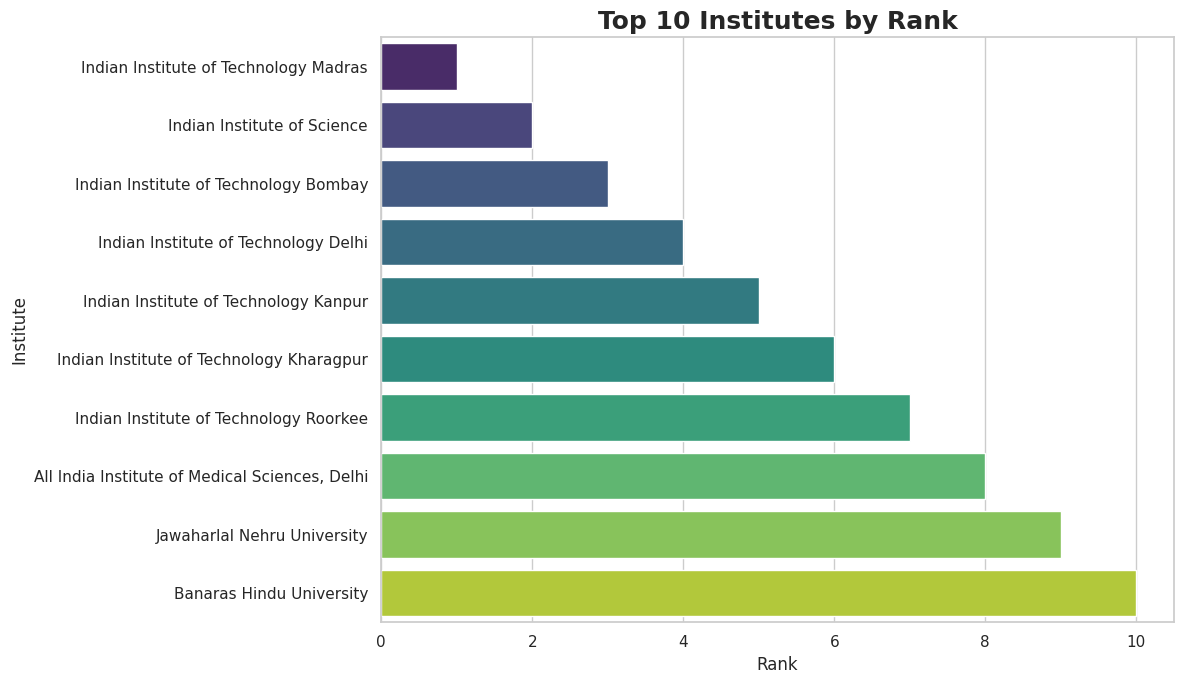

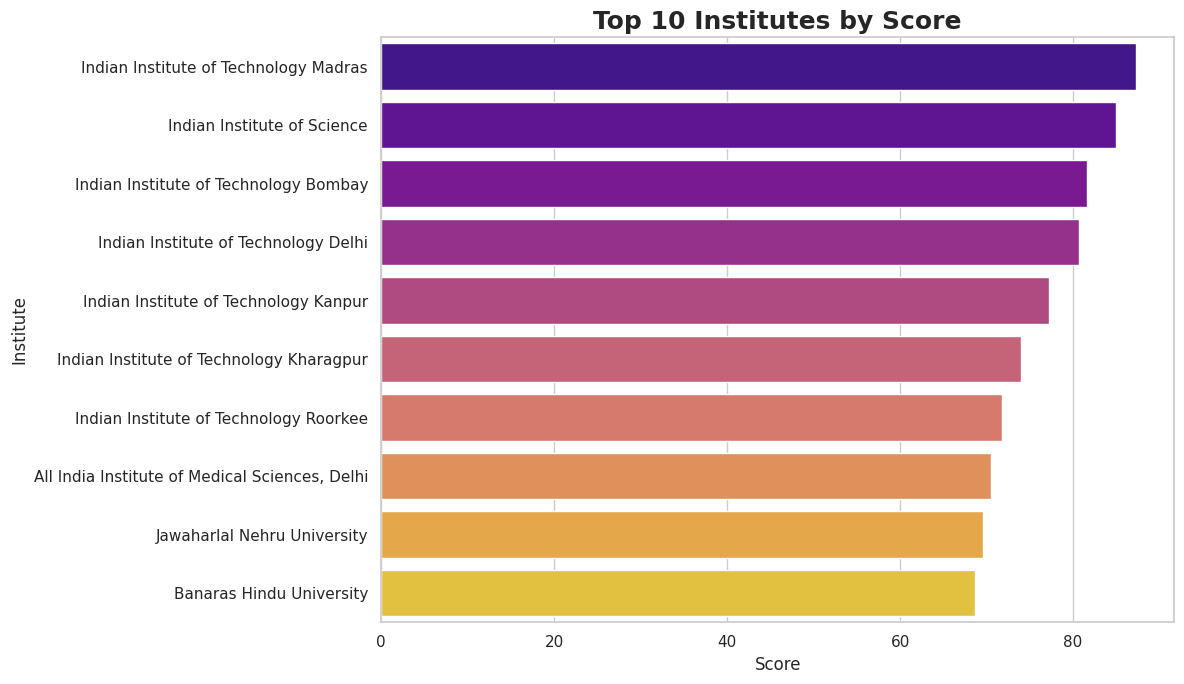

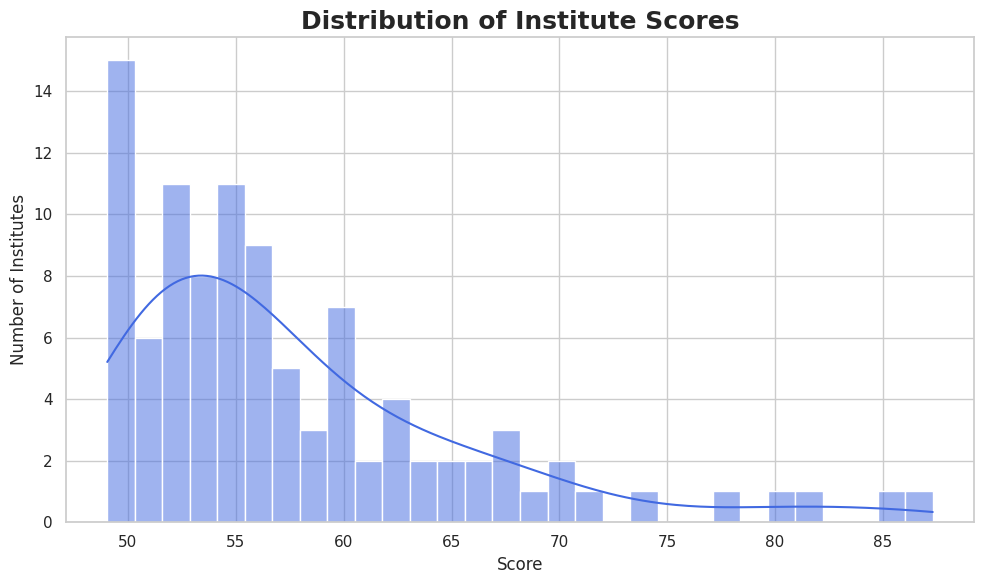

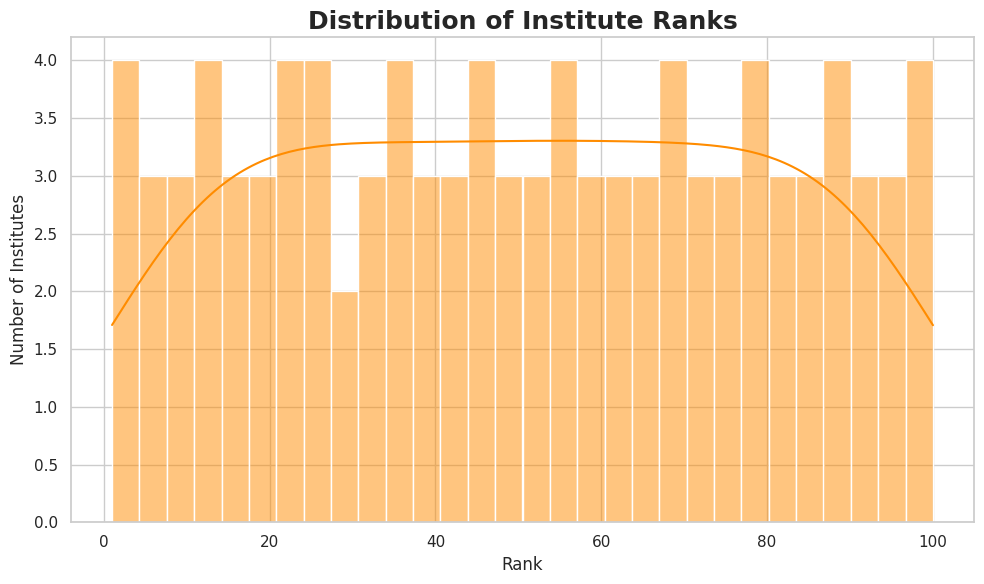

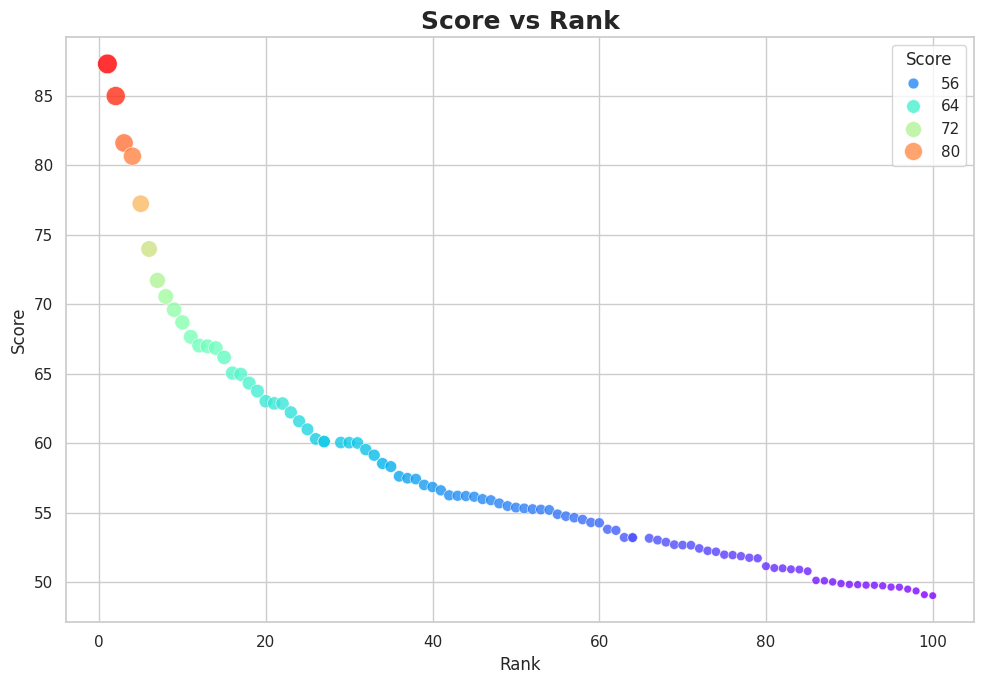

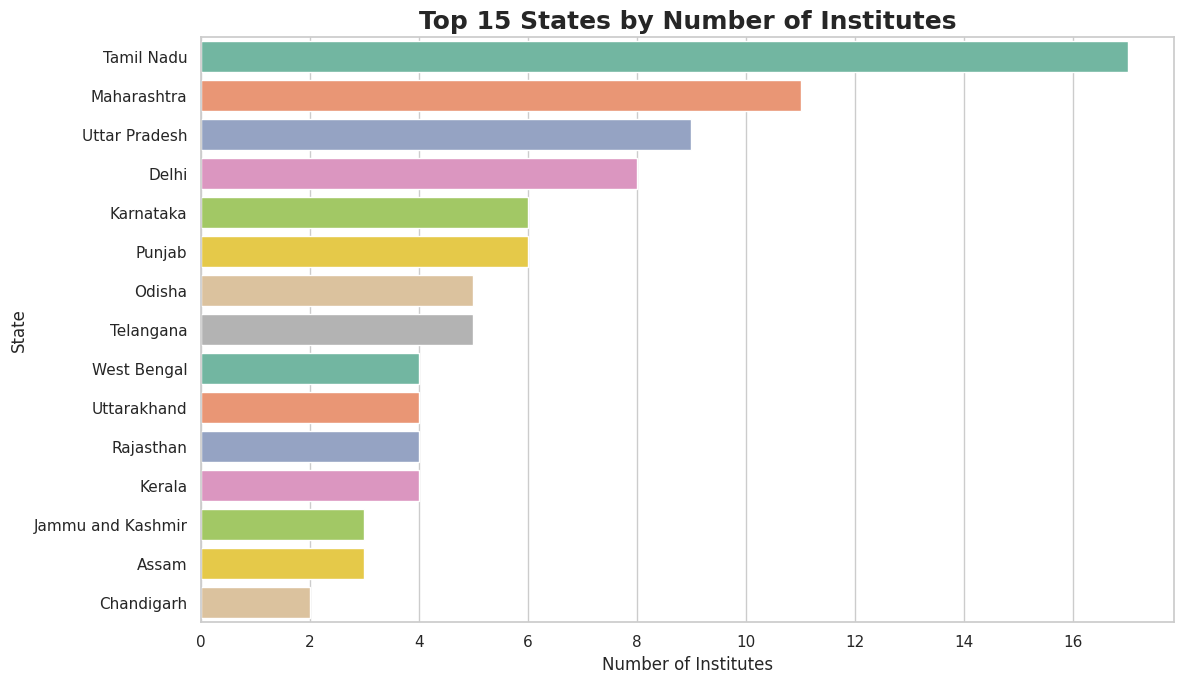

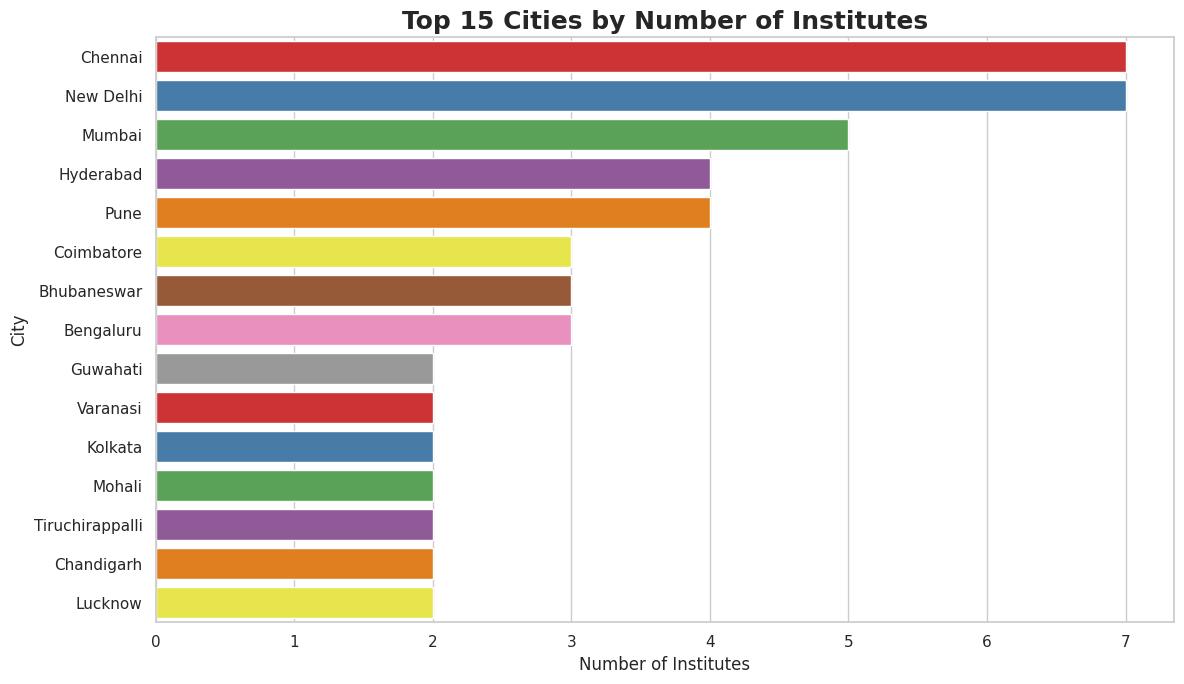

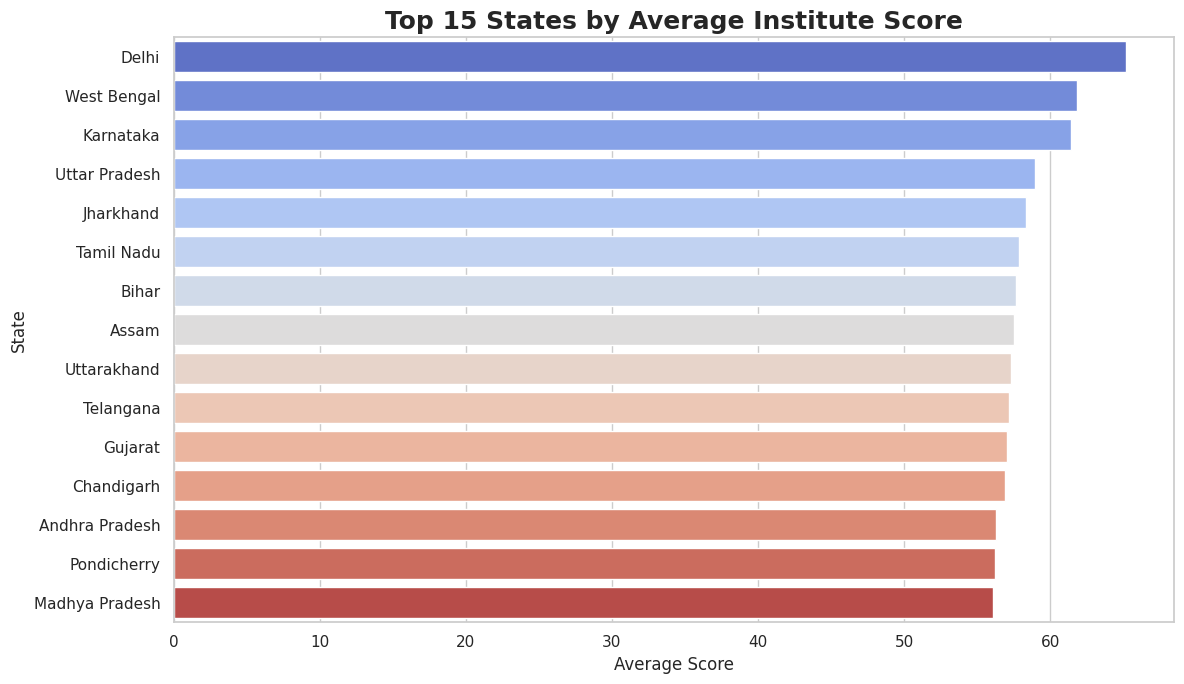

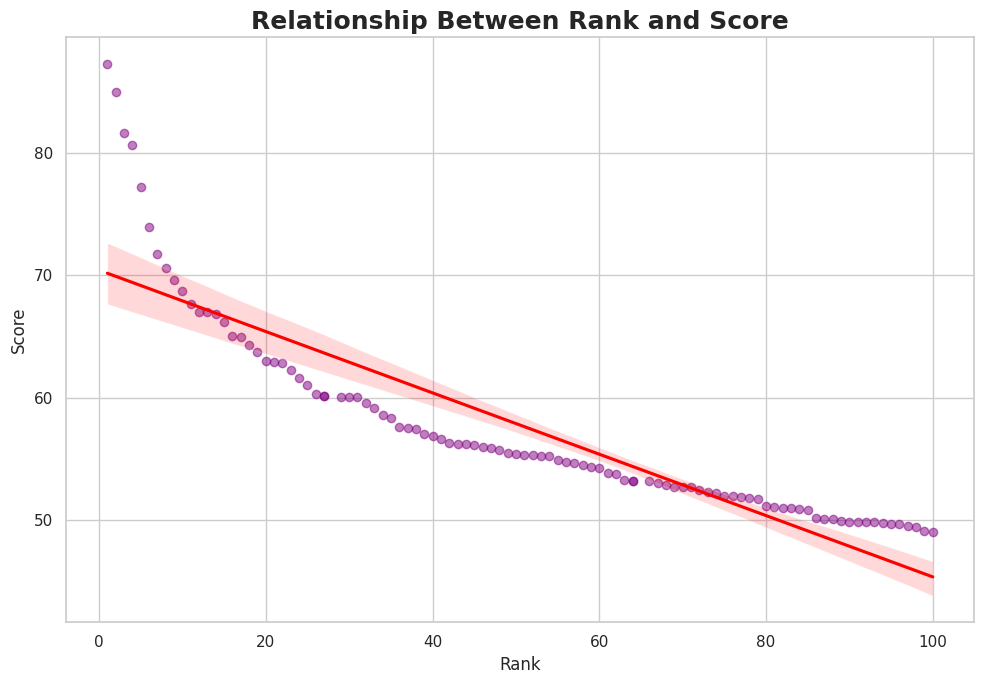

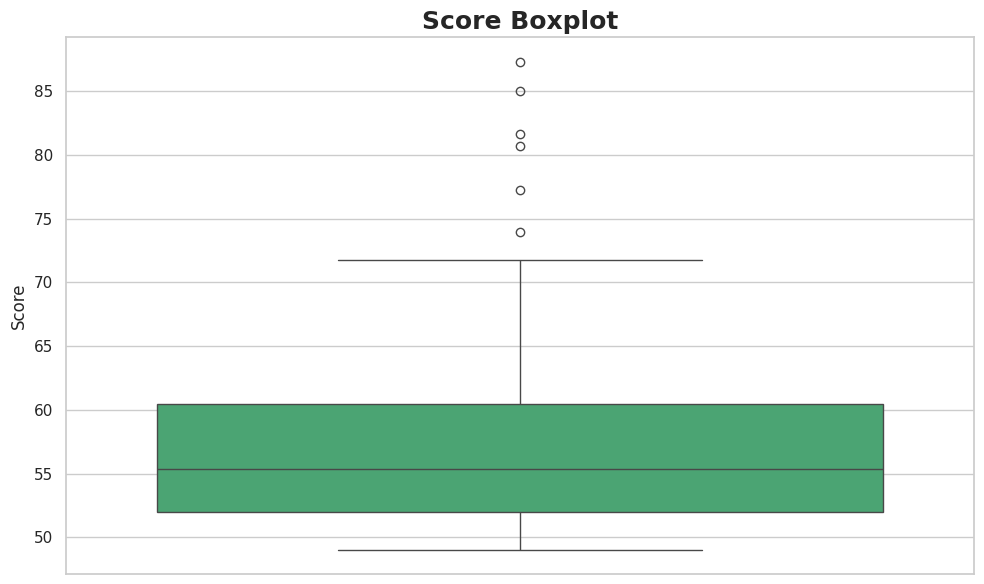

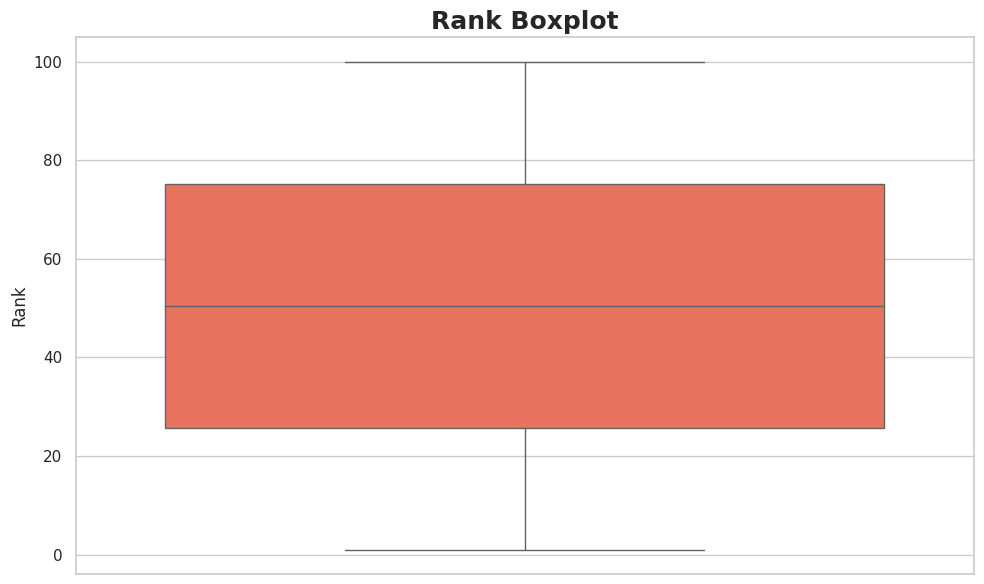

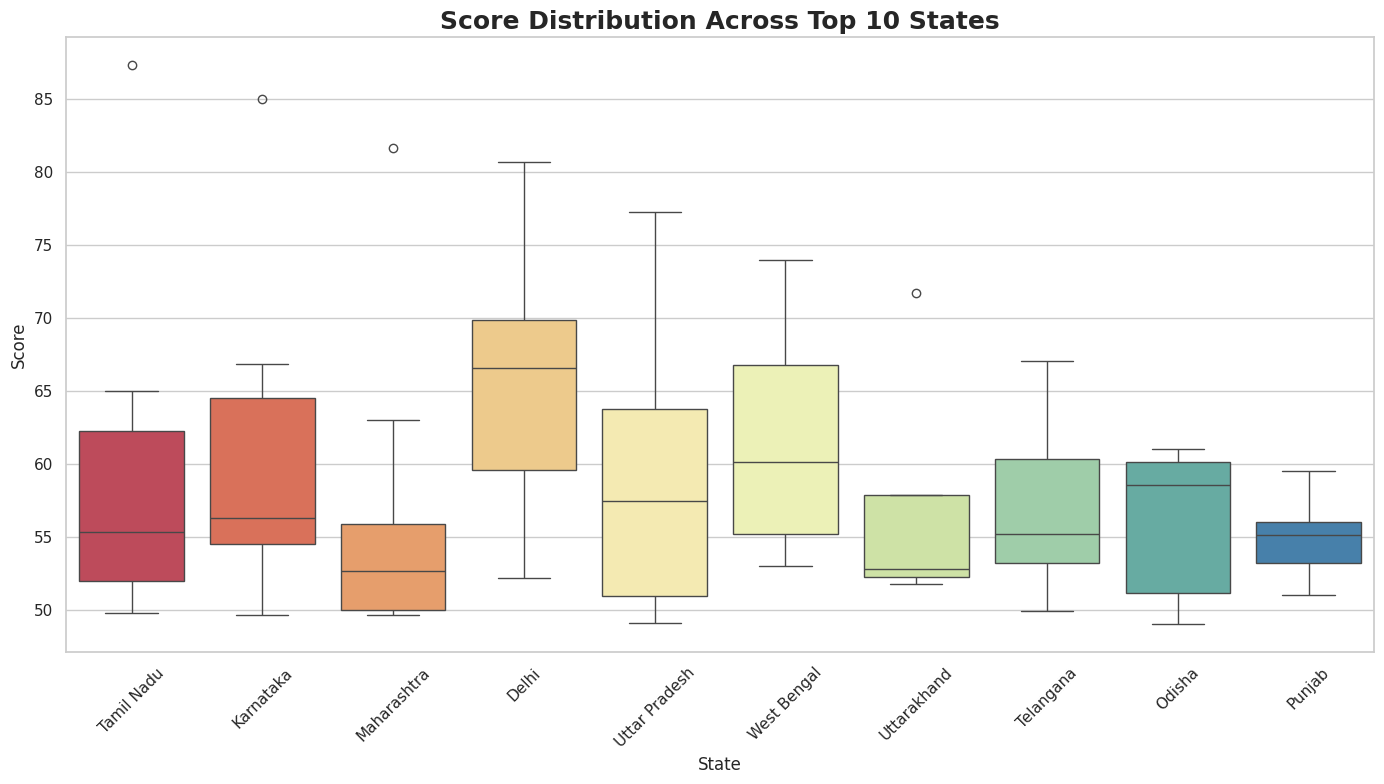

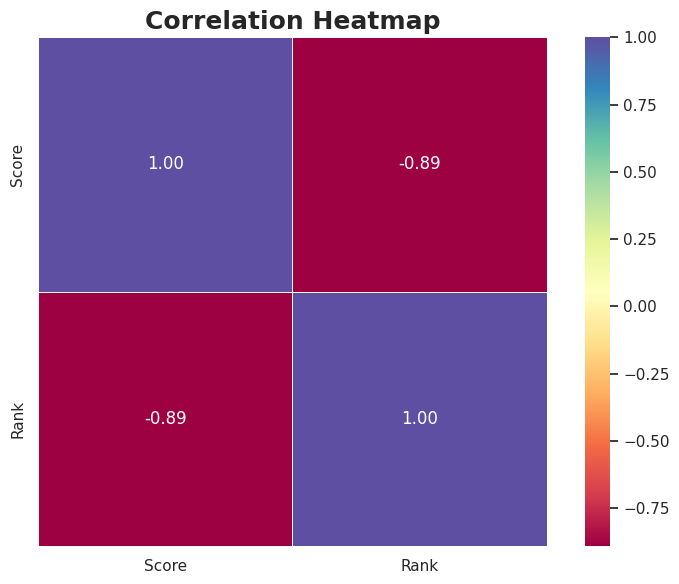

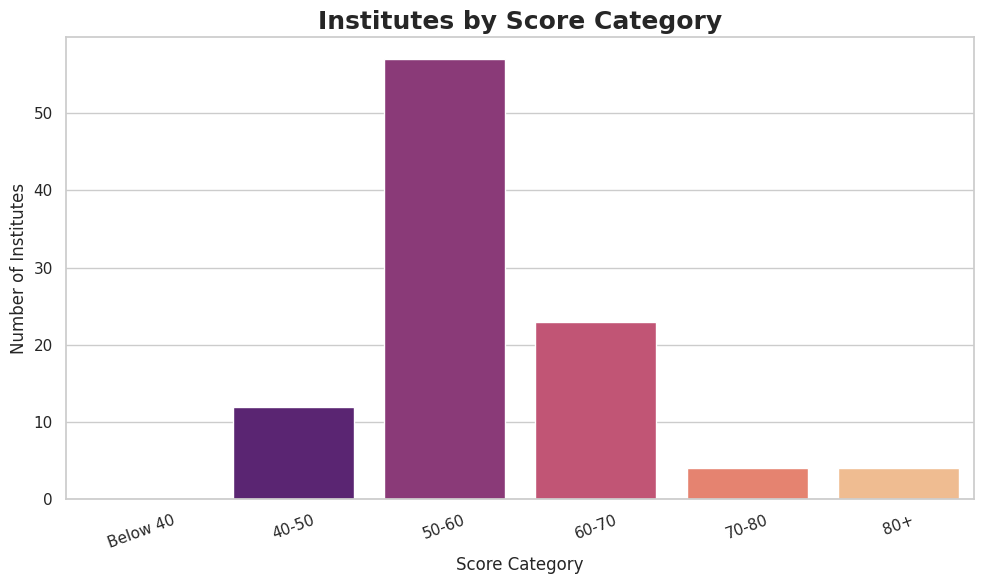

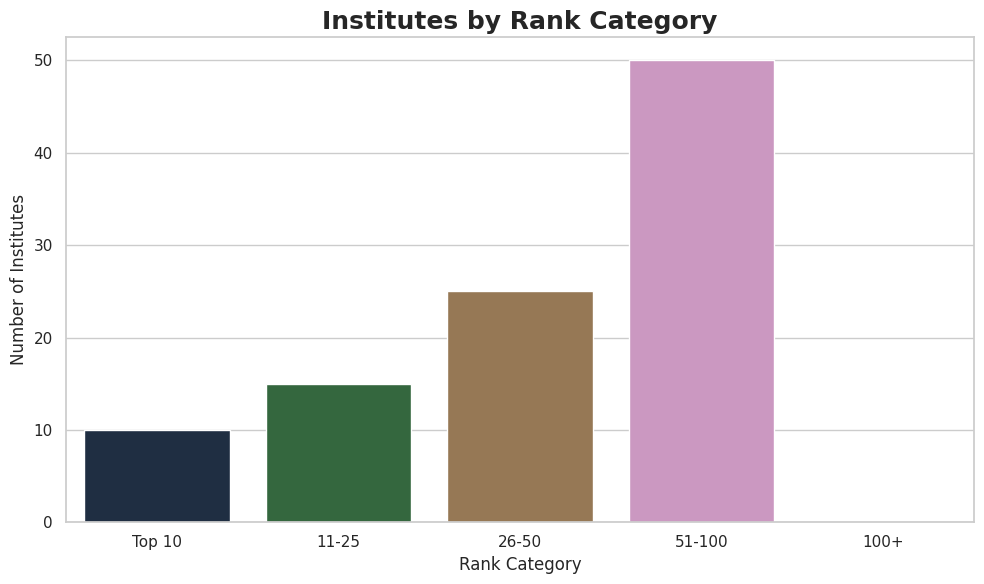

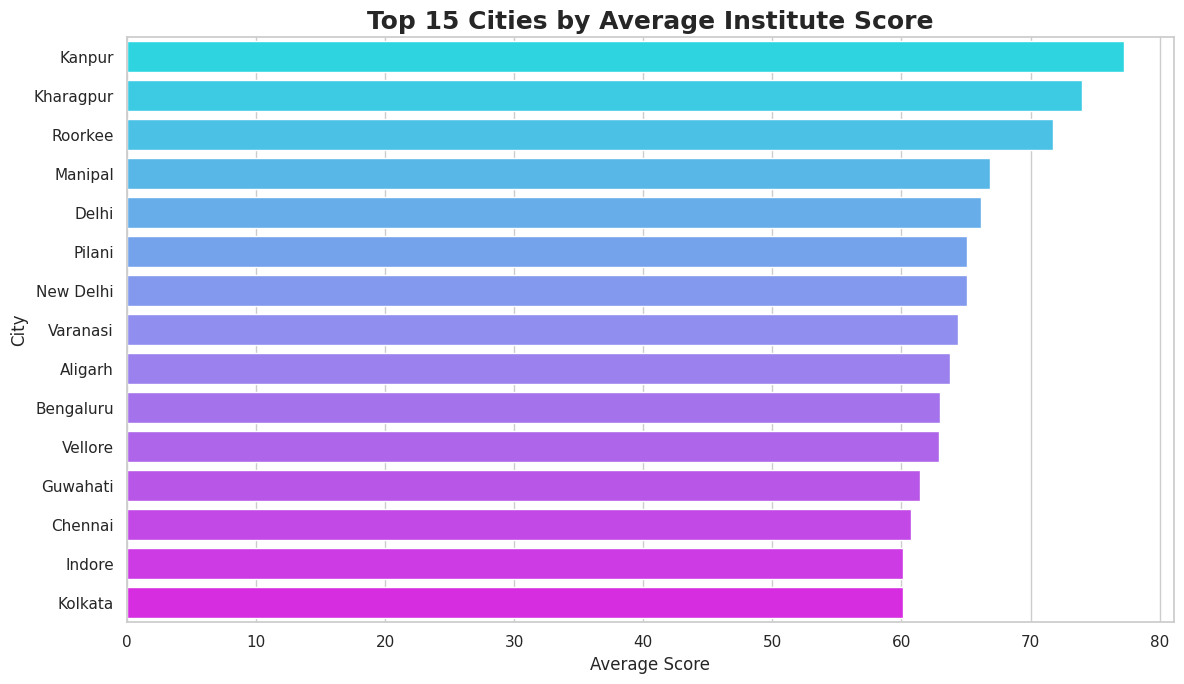


VISUALIZATION COMPLETED SUCCESSFULLY
Number of Institutes: 100
Number of States: 22
Number of Cities: 62

Average Score: 57.76
Highest Score: 87.31
Best Rank: 1
Worst Rank: 100

Remaining NULL values: 0
Remaining duplicates: 0


In [13]:
# ============================================================
# INSTITUTE RANKING DATASET - COMPLETE EDA & VISUALIZATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. COPY DATASET
# ============================================================

data = df.copy()

sns.set_theme(style="whitegrid")

print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)

print("Rows    :", data.shape[0])
print("Columns :", data.shape[1])

print("\nColumn Names:")
print(data.columns.tolist())


# ============================================================
# 2. BASIC INFORMATION
# ============================================================

print("\n" + "=" * 80)
print("FIRST 5 ROWS")
print("=" * 80)

print(data.head())


print("\n" + "=" * 80)
print("DATA TYPES")
print("=" * 80)

print(data.dtypes)


print("\n" + "=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)

print(data.describe(include="all").T)


# ============================================================
# 3. HANDLE NULL VALUES
# ============================================================

print("\n" + "=" * 80)
print("NULL VALUES BEFORE HANDLING")
print("=" * 80)

null_values = data.isnull().sum()

print(
    null_values[
        null_values > 0
    ]
)


# Numeric columns
numeric_columns = data.select_dtypes(
    include=np.number
).columns


# Fill numerical columns with median
for col in numeric_columns:

    if data[col].isnull().sum() > 0:

        data[col] = data[col].fillna(
            data[col].median()
        )


# Categorical columns
categorical_columns = data.select_dtypes(
    include=["object", "category"]
).columns


# Fill categorical columns with mode
for col in categorical_columns:

    if data[col].isnull().sum() > 0:

        mode_value = data[col].mode()

        if len(mode_value) > 0:

            data[col] = data[col].fillna(
                mode_value.iloc[0]
            )

        else:

            data[col] = data[col].fillna(
                "Unknown"
            )


print("\n" + "=" * 80)
print("NULL VALUES AFTER HANDLING")
print("=" * 80)

print(
    data.isnull().sum()[
        data.isnull().sum() > 0
    ]
)

print(
    "\nTotal remaining NULL values:",
    data.isnull().sum().sum()
)


# ============================================================
# 4. HANDLE DUPLICATES
# ============================================================

print("\n" + "=" * 80)
print("DUPLICATE ANALYSIS")
print("=" * 80)

duplicate_count = data.duplicated().sum()

print(
    "Duplicate rows:",
    duplicate_count
)

if duplicate_count > 0:

    data = data.drop_duplicates()

    data.reset_index(
        drop=True,
        inplace=True
    )

    print(
        "Duplicates removed successfully."
    )

else:

    print(
        "No duplicate rows found."
    )

print(
    "Final shape:",
    data.shape
)


# ============================================================
# 5. CONVERT SCORE AND RANK TO NUMERIC
# ============================================================

# This prevents errors if Score or Rank were stored as strings.

data["Score"] = pd.to_numeric(
    data["Score"],
    errors="coerce"
)

data["Rank"] = pd.to_numeric(
    data["Rank"],
    errors="coerce"
)


# Fill any values that became NaN
data["Score"] = data["Score"].fillna(
    data["Score"].median()
)

data["Rank"] = data["Rank"].fillna(
    data["Rank"].median()
)


# ============================================================
# 6. TOP 10 INSTITUTES BY RANK
# ============================================================

top10 = data.sort_values(
    by="Rank",
    ascending=True
).head(10)

plt.figure(
    figsize=(12, 7)
)

sns.barplot(
    data=top10,
    x="Rank",
    y="Name",
    hue="Name",
    palette="viridis",
    legend=False
)

plt.title(
    "Top 10 Institutes by Rank",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Rank")
plt.ylabel("Institute")

plt.tight_layout()
plt.show()


# ============================================================
# 7. TOP 10 INSTITUTES BY SCORE
# ============================================================

top_score = data.sort_values(
    by="Score",
    ascending=False
).head(10)

plt.figure(
    figsize=(12, 7)
)

sns.barplot(
    data=top_score,
    x="Score",
    y="Name",
    hue="Name",
    palette="plasma",
    legend=False
)

plt.title(
    "Top 10 Institutes by Score",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Score")
plt.ylabel("Institute")

plt.tight_layout()
plt.show()


# ============================================================
# 8. SCORE DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.histplot(
    data["Score"],
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title(
    "Distribution of Institute Scores",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Score")
plt.ylabel("Number of Institutes")

plt.tight_layout()
plt.show()


# ============================================================
# 9. RANK DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.histplot(
    data["Rank"],
    bins=30,
    kde=True,
    color="darkorange"
)

plt.title(
    "Distribution of Institute Ranks",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Rank")
plt.ylabel("Number of Institutes")

plt.tight_layout()
plt.show()


# ============================================================
# 10. SCORE VS RANK
# ============================================================

plt.figure(
    figsize=(10, 7)
)

sns.scatterplot(
    data=data,
    x="Rank",
    y="Score",
    hue="Score",
    palette="rainbow",
    size="Score",
    sizes=(30, 200),
    alpha=0.8
)

plt.title(
    "Score vs Rank",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Rank")
plt.ylabel("Score")

plt.tight_layout()
plt.show()


# ============================================================
# 11. TOP STATES BY NUMBER OF INSTITUTES
# ============================================================

state_counts = (
    data["State"]
    .value_counts()
    .head(15)
)

plt.figure(
    figsize=(12, 7)
)

sns.barplot(
    x=state_counts.values,
    y=state_counts.index,
    hue=state_counts.index,
    palette="Set2",
    legend=False
)

plt.title(
    "Top 15 States by Number of Institutes",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Institutes")
plt.ylabel("State")

plt.tight_layout()
plt.show()


# ============================================================
# 12. TOP CITIES BY NUMBER OF INSTITUTES
# ============================================================

city_counts = (
    data["City"]
    .value_counts()
    .head(15)
)

plt.figure(
    figsize=(12, 7)
)

sns.barplot(
    x=city_counts.values,
    y=city_counts.index,
    hue=city_counts.index,
    palette="Set1",
    legend=False
)

plt.title(
    "Top 15 Cities by Number of Institutes",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Institutes")
plt.ylabel("City")

plt.tight_layout()
plt.show()


# ============================================================
# 13. AVERAGE SCORE BY STATE
# ============================================================

state_score = (
    data.groupby("State")["Score"]
    .mean()
    .sort_values(
        ascending=False
    )
    .head(15)
)

plt.figure(
    figsize=(12, 7)
)

sns.barplot(
    x=state_score.values,
    y=state_score.index,
    hue=state_score.index,
    palette="coolwarm",
    legend=False
)

plt.title(
    "Top 15 States by Average Institute Score",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Average Score")
plt.ylabel("State")

plt.tight_layout()
plt.show()


# ============================================================
# 14. SCORE VS RANK REGRESSION
# ============================================================

plt.figure(
    figsize=(10, 7)
)

sns.regplot(
    data=data,
    x="Rank",
    y="Score",
    scatter_kws={
        "alpha": 0.5,
        "color": "purple"
    },
    line_kws={
        "color": "red"
    }
)

plt.title(
    "Relationship Between Rank and Score",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Rank")
plt.ylabel("Score")

plt.tight_layout()
plt.show()


# ============================================================
# 15. SCORE BOXPLOT
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.boxplot(
    y=data["Score"],
    color="mediumseagreen"
)

plt.title(
    "Score Boxplot",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel("Score")

plt.tight_layout()
plt.show()


# ============================================================
# 16. RANK BOXPLOT
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.boxplot(
    y=data["Rank"],
    color="tomato"
)

plt.title(
    "Rank Boxplot",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel("Rank")

plt.tight_layout()
plt.show()


# ============================================================
# 17. SCORE DISTRIBUTION BY TOP STATES
# ============================================================

top_states = (
    data["State"]
    .value_counts()
    .head(10)
    .index
)

state_data = data[
    data["State"].isin(top_states)
]

plt.figure(
    figsize=(14, 8)
)

sns.boxplot(
    data=state_data,
    x="State",
    y="Score",
    hue="State",
    palette="Spectral",
    legend=False
)

plt.title(
    "Score Distribution Across Top 10 States",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("State")
plt.ylabel("Score")

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()


# ============================================================
# 18. CORRELATION HEATMAP
# ============================================================

# IMPORTANT:
# Institute ID is intentionally NOT included because it
# contains values such as IR-O-U-0456 and is an identifier,
# not a numerical variable.

correlation_columns = [
    "Score",
    "Rank"
]

# Keep only existing columns
correlation_columns = [
    col
    for col in correlation_columns
    if col in data.columns
]

correlation = data[
    correlation_columns
].corr()

plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="Spectral",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Heatmap",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 19. SCORE CATEGORY
# ============================================================

data["Score_Category"] = pd.cut(
    data["Score"],
    bins=[
        -np.inf,
        40,
        50,
        60,
        70,
        80,
        np.inf
    ],
    labels=[
        "Below 40",
        "40-50",
        "50-60",
        "60-70",
        "70-80",
        "80+"
    ]
)

score_category = (
    data["Score_Category"]
    .value_counts()
    .sort_index()
)

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    x=score_category.index,
    y=score_category.values,
    hue=score_category.index,
    palette="magma",
    legend=False
)

plt.title(
    "Institutes by Score Category",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Score Category")
plt.ylabel("Number of Institutes")

plt.xticks(
    rotation=20
)

plt.tight_layout()
plt.show()


# ============================================================
# 20. RANK CATEGORY
# ============================================================

data["Rank_Category"] = pd.cut(
    data["Rank"],
    bins=[
        0,
        10,
        25,
        50,
        100,
        np.inf
    ],
    labels=[
        "Top 10",
        "11-25",
        "26-50",
        "51-100",
        "100+"
    ]
)

rank_category = (
    data["Rank_Category"]
    .value_counts()
    .sort_index()
)

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    x=rank_category.index,
    y=rank_category.values,
    hue=rank_category.index,
    palette="cubehelix",
    legend=False
)

plt.title(
    "Institutes by Rank Category",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Rank Category")
plt.ylabel("Number of Institutes")

plt.tight_layout()
plt.show()


# ============================================================
# 21. SCORE BY CITY - TOP 15
# ============================================================

city_score = (
    data.groupby("City")["Score"]
    .mean()
    .sort_values(
        ascending=False
    )
    .head(15)
)

plt.figure(
    figsize=(12, 7)
)

sns.barplot(
    x=city_score.values,
    y=city_score.index,
    hue=city_score.index,
    palette="cool",
    legend=False
)

plt.title(
    "Top 15 Cities by Average Institute Score",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Average Score")
plt.ylabel("City")

plt.tight_layout()
plt.show()


# ============================================================
# 22. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("VISUALIZATION COMPLETED SUCCESSFULLY")
print("=" * 80)

print(
    "Number of Institutes:",
    len(data)
)

print(
    "Number of States:",
    data["State"].nunique()
)

print(
    "Number of Cities:",
    data["City"].nunique()
)

print(
    "\nAverage Score:",
    round(data["Score"].mean(), 2)
)

print(
    "Highest Score:",
    data["Score"].max()
)

print(
    "Best Rank:",
    data["Rank"].min()
)

print(
    "Worst Rank:",
    data["Rank"].max()
)

print(
    "\nRemaining NULL values:",
    data.isnull().sum().sum()
)

print(
    "Remaining duplicates:",
    data.duplicated().sum()
)

## Features Engineering

DATASET
Shape: (100, 6)
  Institute ID                                   Name       City  \
0  IR-O-U-0456  Indian Institute of Technology Madras    Chennai   
1  IR-O-U-0220            Indian Institute of Science  Bengaluru   
2  IR-O-U-0306  Indian Institute of Technology Bombay     Mumbai   
3  IR-O-I-1074   Indian Institute of Technology Delhi  New Delhi   
4  IR-O-I-1075  Indian Institute of Technology Kanpur     Kanpur   

           State  Score  Rank  
0     Tamil Nadu  87.31     1  
1      Karnataka  85.00     2  
2    Maharashtra  81.62     3  
3          Delhi  80.67     4  
4  Uttar Pradesh  77.25     5  

NULL VALUES
Institute ID    0
Name            0
City            0
State           0
Score           0
Rank            0
dtype: int64

Duplicates removed: 0

FEATURE ENGINEERING

TARGET DISTRIBUTION
Rank_Category
Rank_51_100      50
Rank_26_50       25
Rank_11_25       15
Top_10           10
Rank_100_plus     0
Name: count, dtype: int64

FEATURES
['Score', 'Score_Category'

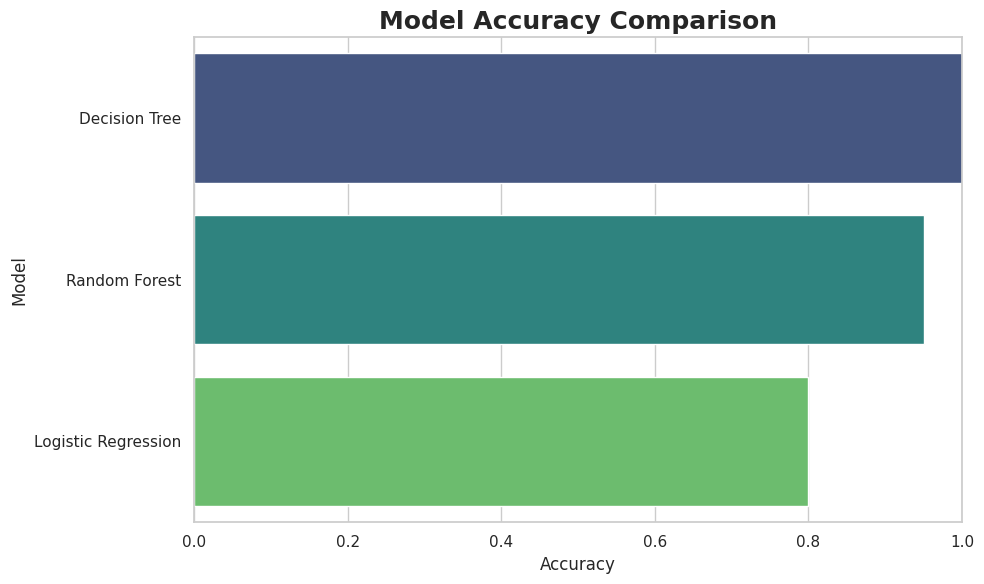

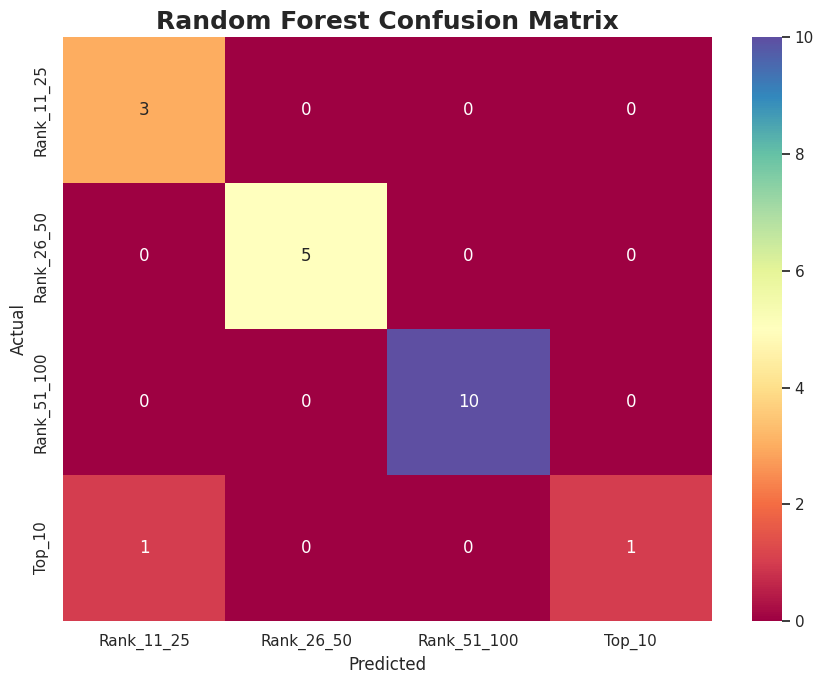


FEATURE ENGINEERING SUMMARY
✓ Score_Category
✓ Score_per_Rank
✓ Log_Rank
✓ Log_Score
✓ High_Score_Flag
✓ Top_Rank_Flag

FINAL RESULT
Best Model: Decision Tree
Best Accuracy: 1.0

Training rows: 80
Testing rows: 20


In [14]:
# ============================================================
# INSTITUTE RANKING - FEATURE ENGINEERING + ML
# TRAIN / TEST + CLASSIFICATION + ACCURACY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. COPY DATA
# ============================================================

data_ml = df.copy()

print("=" * 80)
print("DATASET")
print("=" * 80)

print("Shape:", data_ml.shape)
print(data_ml.head())


# ============================================================
# 2. CLEAN COLUMN NAMES
# ============================================================

data_ml.columns = (
    data_ml.columns
    .str.strip()
)


# ============================================================
# 3. CONVERT SCORE AND RANK TO NUMERIC
# ============================================================

data_ml["Score"] = pd.to_numeric(
    data_ml["Score"],
    errors="coerce"
)

data_ml["Rank"] = pd.to_numeric(
    data_ml["Rank"],
    errors="coerce"
)


# ============================================================
# 4. HANDLE MISSING VALUES
# ============================================================

print("\n" + "=" * 80)
print("NULL VALUES")
print("=" * 80)

print(data_ml.isnull().sum())


# Numerical columns
numeric_cols = data_ml.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:

    data_ml[col] = data_ml[col].fillna(
        data_ml[col].median()
    )


# Categorical columns
categorical_cols = data_ml.select_dtypes(
    include=["object", "category"]
).columns

for col in categorical_cols:

    if data_ml[col].isnull().sum() > 0:

        mode_value = data_ml[col].mode()

        if len(mode_value) > 0:

            data_ml[col] = data_ml[col].fillna(
                mode_value.iloc[0]
            )

        else:

            data_ml[col] = data_ml[col].fillna(
                "Unknown"
            )


# ============================================================
# 5. REMOVE DUPLICATES
# ============================================================

before = len(data_ml)

data_ml = data_ml.drop_duplicates()

data_ml.reset_index(
    drop=True,
    inplace=True
)

after = len(data_ml)

print(
    "\nDuplicates removed:",
    before - after
)


# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================

print("\n" + "=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)


# ------------------------------------------------------------
# Feature 1: Score Category
# ------------------------------------------------------------

data_ml["Score_Category"] = pd.cut(
    data_ml["Score"],
    bins=[
        -np.inf,
        40,
        50,
        60,
        70,
        80,
        np.inf
    ],
    labels=[
        "Below_40",
        "40_50",
        "50_60",
        "60_70",
        "70_80",
        "Above_80"
    ]
)


# ------------------------------------------------------------
# Feature 2: Rank Category
# THIS WILL BE OUR TARGET
# ------------------------------------------------------------

data_ml["Rank_Category"] = pd.cut(
    data_ml["Rank"],
    bins=[
        0,
        10,
        25,
        50,
        100,
        np.inf
    ],
    labels=[
        "Top_10",
        "Rank_11_25",
        "Rank_26_50",
        "Rank_51_100",
        "Rank_100_plus"
    ]
)


# ------------------------------------------------------------
# Feature 3: Score per Rank
# ------------------------------------------------------------

data_ml["Score_per_Rank"] = (
    data_ml["Score"]
    /
    (data_ml["Rank"] + 1)
)


# ------------------------------------------------------------
# Feature 4: Log Rank
# ------------------------------------------------------------

data_ml["Log_Rank"] = np.log1p(
    data_ml["Rank"]
)


# ------------------------------------------------------------
# Feature 5: Log Score
# ------------------------------------------------------------

data_ml["Log_Score"] = np.log1p(
    data_ml["Score"]
)


# ------------------------------------------------------------
# Feature 6: High Score Flag
# ------------------------------------------------------------

data_ml["High_Score_Flag"] = (
    data_ml["Score"] >= 70
).astype(int)


# ------------------------------------------------------------
# Feature 7: Top Rank Flag
# ------------------------------------------------------------

data_ml["Top_Rank_Flag"] = (
    data_ml["Rank"] <= 25
).astype(int)


# ============================================================
# 7. REMOVE ROWS WITH UNKNOWN TARGET
# ============================================================

data_ml = data_ml.dropna(
    subset=["Rank_Category"]
)


# ============================================================
# 8. DISPLAY TARGET DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("TARGET DISTRIBUTION")
print("=" * 80)

print(
    data_ml["Rank_Category"]
    .value_counts()
)


# ============================================================
# 9. IMPORTANT:
# PREVENT TARGET LEAKAGE
# ============================================================

# Rank_Category is created from Rank.
#
# Therefore Rank itself MUST NOT be used as X.
#
# Also features directly derived from Rank must NOT be used:
# Score_per_Rank
# Log_Rank
# Top_Rank_Flag
#
# Otherwise the model would already know the answer.

features = [
    "Score",
    "Score_Category",
    "Log_Score",
    "High_Score_Flag",
    "Name",
    "City",
    "State"
]

target = "Rank_Category"


# ============================================================
# 10. CREATE X AND y
# ============================================================

X = data_ml[features].copy()

y = data_ml[target].copy()


print("\n" + "=" * 80)
print("FEATURES")
print("=" * 80)

print(X.columns.tolist())

print("\nTarget:")
print(target)


# ============================================================
# 11. IDENTIFY DATA TYPES
# ============================================================

numeric_features = [
    "Score",
    "Log_Score",
    "High_Score_Flag"
]

categorical_features = [
    "Score_Category",
    "Name",
    "City",
    "State"
]


# ============================================================
# 12. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\n" + "=" * 80)
print("TRAIN / TEST SPLIT")
print("=" * 80)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ============================================================
# 13. PREPROCESSING
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            __import__(
                "sklearn.preprocessing",
                fromlist=["OneHotEncoder"]
            ).OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ============================================================
# 14. LOGISTIC REGRESSION
# ============================================================

logistic_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000
            )
        )
    ]
)


logistic_model.fit(
    X_train,
    y_train
)


y_pred_lr = logistic_model.predict(
    X_test
)


accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)


print("\n" + "=" * 80)
print("LOGISTIC REGRESSION")
print("=" * 80)

print(
    "Accuracy:",
    round(accuracy_lr, 4)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_lr,
        zero_division=0
    )
)


# ============================================================
# 15. DECISION TREE
# ============================================================

tree_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=8,
                random_state=42
            )
        )
    ]
)


tree_model.fit(
    X_train,
    y_train
)


y_pred_tree = tree_model.predict(
    X_test
)


accuracy_tree = accuracy_score(
    y_test,
    y_pred_tree
)


print("\n" + "=" * 80)
print("DECISION TREE")
print("=" * 80)

print(
    "Accuracy:",
    round(accuracy_tree, 4)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_tree,
        zero_division=0
    )
)


# ============================================================
# 16. RANDOM FOREST
# ============================================================

forest_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


forest_model.fit(
    X_train,
    y_train
)


y_pred_rf = forest_model.predict(
    X_test
)


accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)


print("\n" + "=" * 80)
print("RANDOM FOREST")
print("=" * 80)

print(
    "Accuracy:",
    round(accuracy_rf, 4)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)


# ============================================================
# 17. MODEL ACCURACY COMPARISON
# ============================================================

accuracy_table = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_tree,
        accuracy_rf
    ]

})


accuracy_table = accuracy_table.sort_values(
    by="Accuracy",
    ascending=False
)


print("\n" + "=" * 80)
print("MODEL ACCURACY COMPARISON")
print("=" * 80)

print(
    accuracy_table.to_string(
        index=False
    )
)


# ============================================================
# 18. ACCURACY VISUALIZATION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=accuracy_table,
    x="Accuracy",
    y="Model",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.xlim(0, 1)

plt.title(
    "Model Accuracy Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.tight_layout()
plt.show()


# ============================================================
# 19. CONFUSION MATRIX - RANDOM FOREST
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(
    figsize=(9, 7)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Spectral",
    xticklabels=forest_model.classes_
    if hasattr(forest_model, "classes_")
    else sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.title(
    "Random Forest Confusion Matrix",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()


# ============================================================
# 20. FEATURE ENGINEERING SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 80)

engineered_features = [
    "Score_Category",
    "Score_per_Rank",
    "Log_Rank",
    "Log_Score",
    "High_Score_Flag",
    "Top_Rank_Flag"
]

for feature in engineered_features:

    if feature in data_ml.columns:

        print(
            "✓",
            feature
        )


# ============================================================
# 21. FINAL INFORMATION
# ============================================================

print("\n" + "=" * 80)
print("FINAL RESULT")
print("=" * 80)

print(
    "Best Model:",
    accuracy_table.iloc[0]["Model"]
)

print(
    "Best Accuracy:",
    round(
        accuracy_table.iloc[0]["Accuracy"],
        4
    )
)

print(
    "\nTraining rows:",
    len(X_train)
)

print(
    "Testing rows:",
    len(X_test)
)

## Thanks.............Please Upvote